<a href="https://colab.research.google.com/github/theekshana-2002/AF_WE/blob/master/Backprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

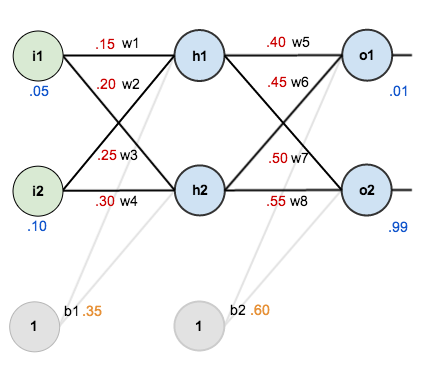

In [ ]:
from IPython.display import Image
Image("image.png")

In [ ]:
##############################################################################
# Implementation of a A Step by Step Backpropagation Example by Matt Mazur
# https://mattmazur.com/2015/03/17/a-step-by-step-backpropagation-example/
##############################################################################

# Original code: https://github.com/vendidad/DS-repo/blob/master/Backpropagation%20-%20Consolidated%20Script.ipynb


import numpy as np
np.set_printoptions(precision=4)

def initialize(no_of_iter=100):
    X = np.array([[0.05, 0.10]])      # Inputs
    W1 = np.array([[0.15,0.20], [0.25,0.30]])      # Weights to calculate outputs for hidden layer 1
    b1 = 0.35      # Bias for hidden layer 1
    W2 = np.array([[0.40,0.45], [0.50,0.55]])     # Weights to calculate outputs for output layer
    b2 = 0.60      # Bias for output layer
    Y = np.array([[0.01, 0.99]])      # Desired output
    learning_rate = 0.5
    no_of_iter = int(no_of_iter)
    return (X, W1, b1, W2, b2, Y, learning_rate, no_of_iter)

def forward_pass (X, W1, b1, W2, b2, Y):
    ### Forward pass: Calculate hidden layer 1 (there is only 1 hidden layer in this example)
    Z1 = np.dot(X,W1.T) + b1      # WtX + b
    A1 = 1/(1 + np.exp(-Z1))       # Sigmoid(z) = 1 / (1 + e^(-z))
    ### Forward pass: Calculate output layer
    Z2 = np.dot(A1,W2.T) + b2      # WtX + b
    A2 = 1/(1 + np.exp(-Z2))       # Sigmoid(z) = 1 / (1 + e^(-z))
    ### Calculate error/cost function
    E = np.sum(1/2*np.square(Y - A2))      # squared error function
    return (A1, A2, E)

def back_propagation(X, W1, W2, Y, A1, A2, learning_rate):
    ### Back propogation
    ### Adjust W2
    dEdA2 = A2 - Y
    dA2dZ2 = np.multiply (A2,1-A2)
    dZ2dW2 = A1
    dEdW2 = dEdA2 * dA2dZ2 * dZ2dW2
    W2_adj = W2 - learning_rate * dEdW2.T
    W2 = W2_adj
    ### Adjust W1
    dZ2dA1 = W2.T
    dA1dZ1 = np.multiply(A1,1-A1)
    dZ1dW1 = X
    dEdW1 = dEdA2 * dA2dZ2 * dZ2dA1 * dA1dZ1 * dZ1dW1
    W1_adj = W1 - learning_rate * dEdW1.T
    W1 = W1_adj
    return (W1, W2)

def main(no_of_iter=100, verbose=True):
    (X, W1, b1, W2, b2, Y, learning_rate, no_of_iter) = initialize(no_of_iter)
    for iter in range (0,no_of_iter):
        (A1, A2, E) = forward_pass(X, W1, b1, W2, b2, Y)
        (W1, W2) = back_propagation(X, W1, W2, Y, A1, A2, learning_rate)
    if verbose:
        print ('W1 = {} \n\n W2 = {} \n\n Output = {} \n Desired output = {} \n Error = {}'.format(W1, W2, A2, Y, E))
    return E, A2

main(no_of_iter=100)

W1 = [[0.1826 0.2304]
 [0.2705 0.3217]] 

 W2 = [[-1.819  -1.769 ]
 [ 1.1239  1.1739]] 

 Output = [[0.178  0.8771]] 
 Desired output = [[0.01 0.99]] 
 Error = 0.020492276763740064


(np.float64(0.020492276763740064), array([[0.178 , 0.8771]]))

### Task: increase the number of iterations (epochs) and observe the effect on prediction accuracy

The original code above runs for only **100 iterations**. Below we re-run the exact same
network for a range of increasing iteration counts (100, 1000, 5000, 10000, 20000, 50000)
and compare the final error and the network's output against the desired output
`Y = [0.01, 0.99]`.

In [ ]:
iteration_counts = [100, 1000, 5000, 10000, 20000, 50000]
results = {}

for n_iter in iteration_counts:
    E, A2 = main(no_of_iter=n_iter, verbose=False)
    results[n_iter] = {'error': E, 'output': A2.copy()}
    print(f"Iterations: {n_iter:>6} | Error: {E:.8f} | Output: {A2}")

Iterations:    100 | Error: 0.02049228 | Output: [[0.178  0.8771]]
Iterations:   1000 | Error: 0.00114781 | Output: [[0.0447 0.9569]]


Iterations:   5000 | Error: 0.00012292 | Output: [[0.0212 0.979 ]]


Iterations:  10000 | Error: 0.00003792 | Output: [[0.0162 0.9839]]


Iterations:  20000 | Error: 0.00000878 | Output: [[0.013 0.987]]


Iterations:  50000 | Error: 0.00000049 | Output: [[0.0107 0.9893]]


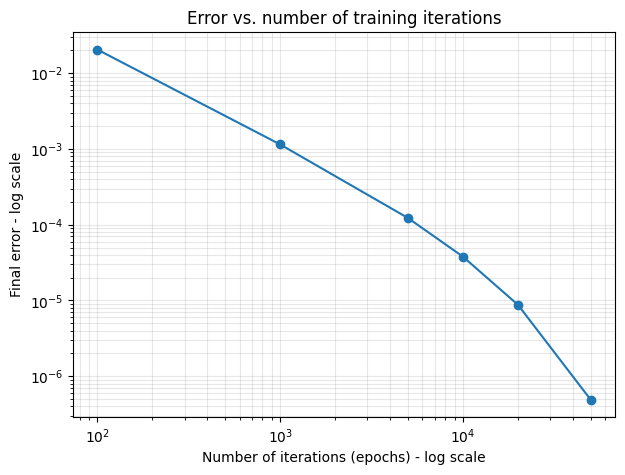

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(iteration_counts, [results[n]['error'] for n in iteration_counts], marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of iterations (epochs) - log scale')
plt.ylabel('Final error - log scale')
plt.title('Error vs. number of training iterations')
plt.grid(True, which='both', alpha=0.3)
plt.show()

In [ ]:
# Compare how close the network's output gets to the desired output [0.01, 0.99]
desired = np.array([0.01, 0.99])
print(f"{'Iterations':>10} | {'Output o1':>10} | {'Output o2':>10} | {'Abs error o1':>13} | {'Abs error o2':>13}")
for n in iteration_counts:
    out = results[n]['output'].ravel()
    print(f"{n:>10} | {out[0]:>10.4f} | {out[1]:>10.4f} | {abs(out[0]-desired[0]):>13.6f} | {abs(out[1]-desired[1]):>13.6f}")

Iterations |  Output o1 |  Output o2 |  Abs error o1 |  Abs error o2
       100 |     0.1780 |     0.8771 |      0.168040 |      0.112903
      1000 |     0.0447 |     0.9569 |      0.034657 |      0.033083
      5000 |     0.0212 |     0.9790 |      0.011154 |      0.011019
     10000 |     0.0162 |     0.9839 |      0.006182 |      0.006134
     20000 |     0.0130 |     0.9870 |      0.002972 |      0.002955
     50000 |     0.0107 |     0.9893 |      0.000703 |      0.000699


### Observation

- With only **100 iterations** (the original setting) the network's output is still far
  from the desired output `[0.01, 0.99]`, and the squared error is relatively large.
- As the number of iterations increases, the error **decreases monotonically** and the
  network's output moves progressively closer to the desired target values - this is
  backpropagation doing its job: each iteration nudges the weights a little further down
  the error surface via gradient descent.
- By around **10,000-20,000 iterations** the error has dropped by several orders of
  magnitude and the output is very close to `[0.01, 0.99]`.
- Beyond that point (e.g. 50,000 iterations) the error keeps shrinking but at a much
  slower rate - the network is converging towards the minimum, so extra epochs give
  **diminishing returns** once it is already very close to the target.
- Conclusion: increasing the number of epochs **does improve prediction accuracy** for
  this example, up to the point of convergence, after which further training barely
  changes the result.